In [128]:
import pandas as pd
import matplotlib.pyplot as plt

In [129]:
dataset_path = "dataset/dataset-uf250-1065.csv"
df = pd.read_csv(dataset_path)

# replace NaN values in 'option' by 'default'
df['option'] = df['option'].fillna('default')
df = df.fillna(0)
# remove the ' ms' from the 'Time' column and convert it to float
df['Propagation'] = df['Propagation'] - df["Skipped Propagation"] - df["Replayed Propagation"]

print(df.columns)


Index(['file', 'option', 'Time (ms)', 'Notifications', 'Done', 'Clause added',
       'Decision', 'Implication', 'Unassignement', 'Propagation', 'Conflict',
       'Skipped Propagation', 'Re-deciding Last Backtracked',
       'Replayed Propagation', 'Sync unassign', 'Weight tie', 'Restart',
       'Sync assign', 'Learned clause', 'Time', 'Clause deleted',
       'Missed lower implication logged', 'Missed lower implication removed',
       'Identical clause found', 'Cross implication for decision',
       'Root level literal'],
      dtype='object')


In [130]:
# add the scaled down columns (divided by 1000, 1000000) if they exist
for col in df.columns:
    if col in ['file', 'option']:
        continue
    # if numeric column
    if pd.api.types.is_numeric_dtype(df[col]):
        if df[col].max() > 1000000:
            df[col + ' x10^6'] = df[col] / 1000000
        if df[col].max() > 1000:
            df[col + ' x10^3'] = df[col] / 1000

# if the column 'Time (ms) x10^3' exists, rename it to 'Time (s)'
if 'Time (ms) x10^3' in df.columns:
    df = df.rename(columns={'Time (ms) x10^3': 'Time (s)'})

In [131]:
# print(f"Average number of cross implication for decision filtered {filtered[filtered['option'] == '-gb']['Cross implication for decision'].mean()}")
# print(f"Average number of cross implication for decision df {df[df['option'] == '-gb']['Cross implication for decision'].mean()}")

In [132]:
options = df['option'].unique()

df_options = {opt: df[df['option'] == opt] for opt in options}

In [133]:
is_unsat = 'uuf' in dataset_path
n_vars = dataset_path.split('uf')[-1].split('-')[0]
if is_unsat:
    print("UNSAT", end=' ')
else:
    print("SAT", end=' ')
print(f"dataset with {int(len(df) / len(df_options))} problems with {n_vars} variables.")
columns = ["option"]
for col in df.columns:
    if col not in ['file', 'option']:
        columns.append(col + " mean")
        columns.append(col + " median")

stats = pd.DataFrame(columns=columns)
for opt, df in df_options.items():
    row = {}
    row['option'] = opt
    for col in df.columns:
        if col not in ['file', 'option']:
            row[col + " mean"] = df[col].mean()
            row[col + " median"] = df[col].median()
    stats.loc[-1] = row
    stats.index = stats.index + 1
stats = stats[['option', 'Time (ms) mean', 'Time (ms) median', 'Propagation x10^3 mean', 'Propagation x10^3 median', 'Sync assign x10^3 mean', 'Sync assign x10^3 median', 'Cross implication for decision mean']]
stats

SAT dataset with 100 problems with 250 variables.


,option,Time (ms) mean,Time (ms) median,Propagation x10^3 mean,Propagation x10^3 median,Sync assign x10^3 mean,Sync assign x10^3 median,Cross implication for decision mean
2,default,6231.16,4143.0,3090.53685,2628.458,558.06127,483.5675,0.00
1,-gb,13112.96,7047.0,4437.34452,3384.945,430.15105,327.0730,0.00
0,-gb -lcm,10316.18,4708.5,3703.40720,2680.487,362.44913,262.2695,22381.54


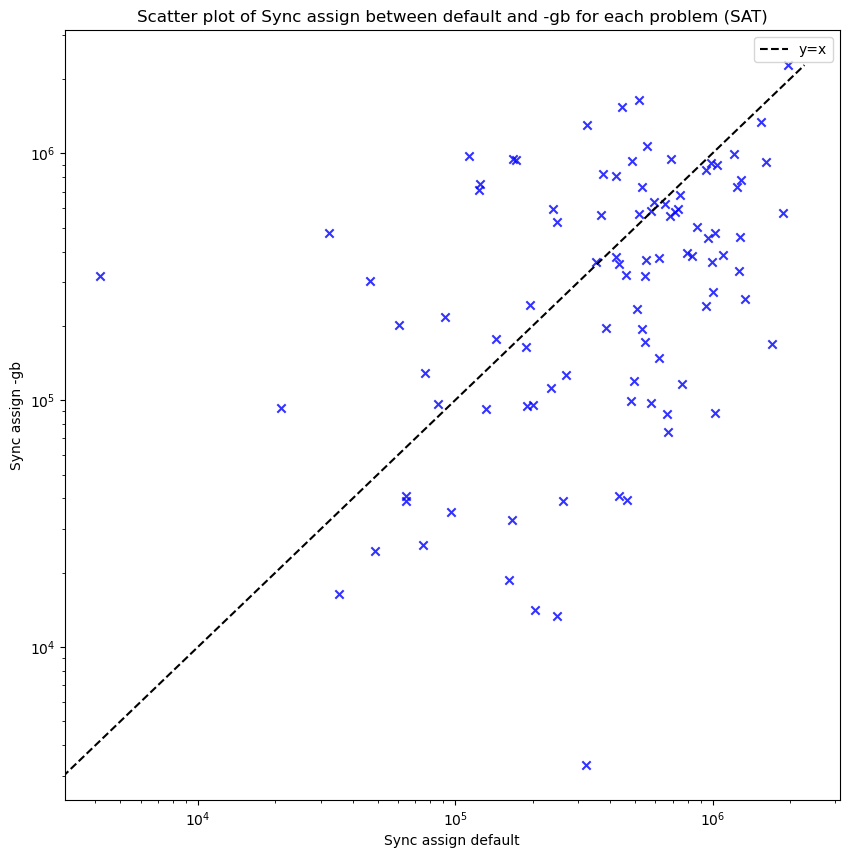

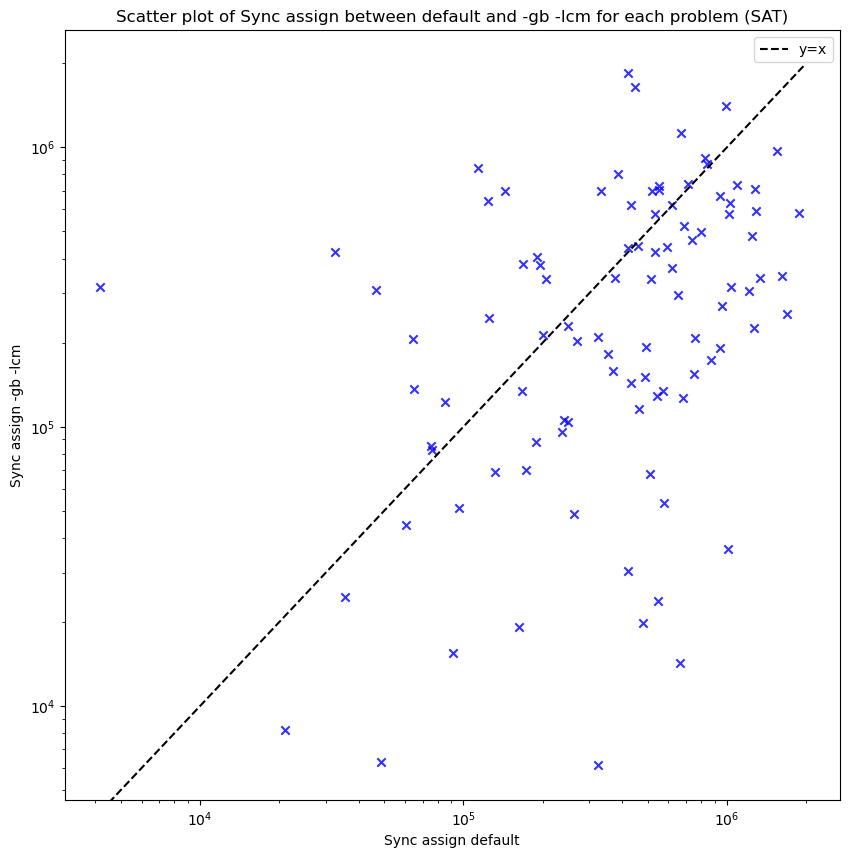

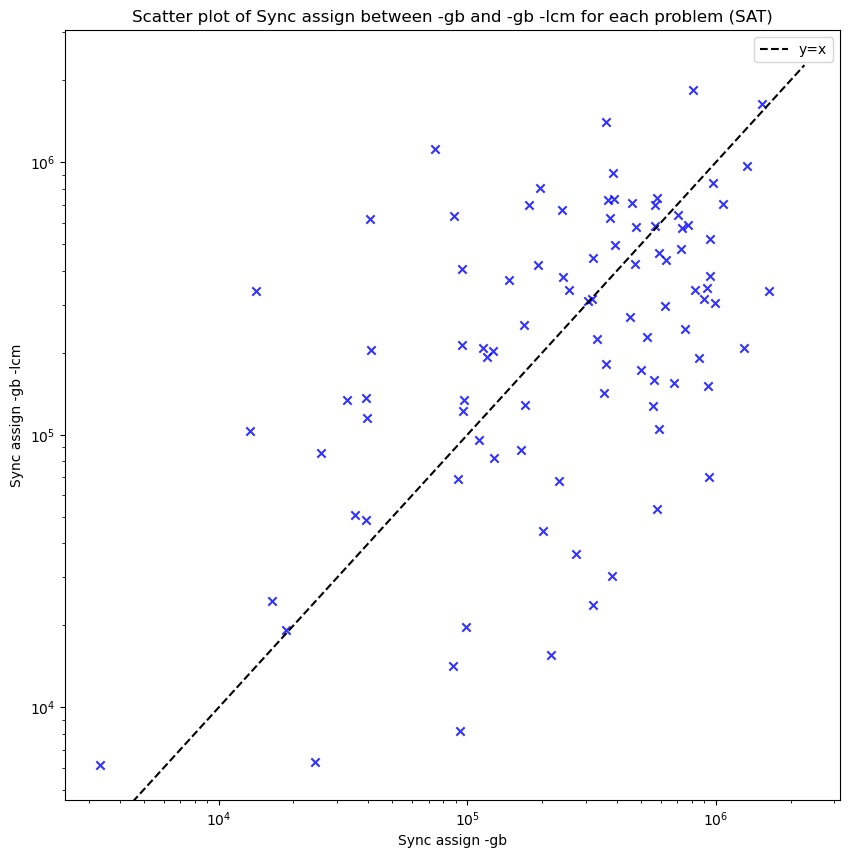

In [134]:
# create a scatter plot of the ratio of time between -gb and default for each file

for i, opt in enumerate(options):
    for opt2 in options[i+1:]:
        plt.figure(figsize=(10, 10))
        plt.title(f"Scatter plot of Sync assign between {opt} and {opt2} for each problem " + ("(UNSAT)" if is_unsat else "(SAT)"))
        plt.scatter(df_options[opt]['Sync assign'], df_options[opt2]['Sync assign'], color='blue', alpha=0.8, marker='x')

        # axis equal
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Sync assign ' + opt)
        plt.ylabel('Sync assign ' + opt2)

        minimum = min(df_options[opt]['Sync assign'].min(),
                    df_options[opt2]['Sync assign'].min())
        maximum = max(df_options[opt]['Sync assign'].max(),
                    df_options[opt2]['Sync assign'].max())

        plt.plot([minimum, maximum], [minimum, maximum], color='black', linestyle='--', label='y=x')
        plt.legend()
